In [1]:
import arcpy
from arcpy.conversion import ConvertLas, LasDatasetToRaster
from arcpy.ia import Hillshade
from arcpy.management import MakeLasDatasetLayer, MosaicToNewRaster

project = arcpy.mp.ArcGISProject("CURRENT")

In [2]:
# Set the workspace directory
arcpy.env.workspace = r"C:\GEOG6480\Lab03\LAZ"

In [3]:
# Set the output coordinate system
arcpy.env.outputCoordinateSystem = arcpy.SpatialReference(26917)

In [4]:
# List all the .laz files
laz_list: list[str] = arcpy.ListFiles("*.laz")

In [5]:
# Print out the filenames without extension
for i in laz_list:
    print(i.rstrip(".laz"))

1km176210483402015LGTA2015_CPC
1km176220483002015LGTA2015_CPC
1km176220483102015LGTA2015_CPC
1km176220483202015LGTA2015_CPC
1km176220483302015LGTA2015_CPC
1km176220483402015LGTA2015_CPC
1km176230483002015LGTA2015_CPC
1km176230483102015LGTA2015_CPC
1km176230483202015LGTA2015_CPC
1km176230483302015LGTA2015_CPC
1km176230483402015LGTA2015_CPC
1km176240483102015LGTA2015_CPC
1km176240483202015LGTA2015_CPC
1km176240483302015LGTA2015_CPC
1km176240483402015LGTA2015_CPC
1km176250483102015LGTA2015_CPC
1km176250483202015LGTA2015_CPC
1km176250483302015LGTA2015_CPC
1km176250483402015LGTA2015_CPC
1km176260483102015LGTA2015_CPC
1km176260483202015LGTA2015_CPC
1km176260483302015LGTA2015_CPC
1km176260483402015LGTA2015_CPC
1km176270483102015LGTA2015_CPC
1km176270483202015LGTA2015_CPC
1km176270483302015LGTA2015_CPC
1km176270483402015LGTA2015_CPC
1km176280483002015LGTA2015_CPC
1km176280483102015LGTA2015_CPC
1km176280483202015LGTA2015_CPC
1km176280483302015LGTA2015_CPC
1km176280483402015LGTA2015_CPC
1km17629

In [6]:
# Convert LAZ to LAS
for laz in laz_list:
    ConvertLas(
        in_las=laz,
        target_folder=r"C:\GEOG6480\Lab03\LAS",
        define_coordinate_system="FILES_MISSING_PROJECTION",
        in_coordinate_system=arcpy.env.outputCoordinateSystem
    )

In [8]:
arcpy.env.workspace = r"C:\GEOG6480\Lab03\LAS"
las_list: list[str] = arcpy.ListFiles("*.las")
for i, las in enumerate(las_list):
    print(f"{i + 1}/{len(las_list)}: {las}")
    layer_name: str = las.rstrip(".las")
    MakeLasDatasetLayer(
        in_las_dataset=las, 
        out_layer=layer_name
    )
    LasDatasetToRaster(
        in_las_dataset=layer_name, 
        out_raster=f"C:\\GEOG6480\\Lab03\\Lab03.gdb\\a{las.rstrip('.las')}", 
        interpolation_type="BINNING AVERAGE LINEAR", 
        data_type="FLOAT", 
        sampling_type="CELLSIZE", 
        sampling_value=0.5
    )
    arcpy.management.Delete(layer_name)

0/37: 1km176210483402015LGTA2015_CPC.las
1/37: 1km176220483002015LGTA2015_CPC.las
2/37: 1km176220483102015LGTA2015_CPC.las
3/37: 1km176220483202015LGTA2015_CPC.las
4/37: 1km176220483302015LGTA2015_CPC.las
5/37: 1km176220483402015LGTA2015_CPC.las
6/37: 1km176230483002015LGTA2015_CPC.las
7/37: 1km176230483102015LGTA2015_CPC.las
8/37: 1km176230483202015LGTA2015_CPC.las
9/37: 1km176230483302015LGTA2015_CPC.las
10/37: 1km176230483402015LGTA2015_CPC.las
11/37: 1km176240483102015LGTA2015_CPC.las
12/37: 1km176240483202015LGTA2015_CPC.las
13/37: 1km176240483302015LGTA2015_CPC.las
14/37: 1km176240483402015LGTA2015_CPC.las
15/37: 1km176250483102015LGTA2015_CPC.las
16/37: 1km176250483202015LGTA2015_CPC.las
17/37: 1km176250483302015LGTA2015_CPC.las
18/37: 1km176250483402015LGTA2015_CPC.las
19/37: 1km176260483102015LGTA2015_CPC.las
20/37: 1km176260483202015LGTA2015_CPC.las
21/37: 1km176260483302015LGTA2015_CPC.las
22/37: 1km176260483402015LGTA2015_CPC.las
23/37: 1km176270483102015LGTA2015_CPC.las
24

In [2]:
print("Moved on to the mosaic and hillshade stage...")

arcpy.env.workspace = r"C:\GEOG6480\Lab03\Lab03.gdb"
print(f"Current work space: {arcpy.env.workspace}")

dsm_rasters_list: list[str] = arcpy.ListRasters("a1km*")
for i in dsm_rasters_list:
    print(i)

Moved on to the mosaic and hillshade stage...
Current work space: C:\GEOG6480\Lab03\Lab03.gdb


In [3]:
MosaicToNewRaster(
    input_rasters=dsm_rasters_list, 
    output_location=arcpy.env.workspace, 
    raster_dataset_name_with_extension="HumberBayMozaic", 
    # {coordinate_system_for_the_raster}, 
    # {pixel_type}, 
    # {cellsize}, 
    number_of_bands=1, 
    # {mosaic_method}, 
    # {mosaic_colormap_mode}
)

<class 'arcgisscripting.ExecuteError'>: Failed to execute. Parameters are not valid.
ERROR 000735: Input Rasters: Value is required
Failed to execute (MosaicToNewRaster).


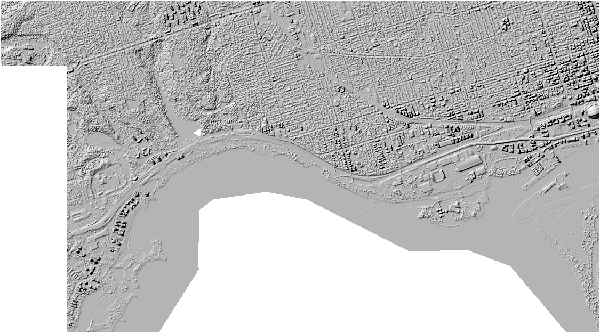

In [18]:
Hillshade(
    dem="HumberBayMozaic", 
    azimuth=175.26, 
    altitude=45.98, 
    # {z_factor}, 
    # {slope_type}, 
    # {ps_power}, 
    # {psz_factor}, 
    # {remove_edge_effect}, 
    # {hillshade_type}
)

In [20]:
out_hillshade_raster = Hillshade(
    dem="HumberBayMozaic", 
    azimuth=175.26, 
    altitude=45.98, 
    # {z_factor}, 
    # {slope_type}, 
    # {ps_power}, 
    # {psz_factor}, 
    # {remove_edge_effect}, 
    # {hillshade_type}
)
out_hillshade_raster.save(r"C:\GEOG6480\Lab03\hillshade2.tif")

In [12]:
# Save changes
project.save()
print("Complete!")

Complete!


In [4]:
print("Part3")
filename_mosaic_root: str = "HumberBayMozaic"

for i in [3, 5, 7, 9]:
    kernel_width: int = i
    kernel_height: int  = i
    kernel = arcpy.sa.NbrRectangle(kernel_width, kernel_height, "CELL")
    
    # Focal Statistics
    print(f"Focal Statistics {i}x{i} ...")
    std_filter = arcpy.sa.FocalStatistics(
        in_raster=filename_mosaic_root, 
        neighborhood=kernel, 
        statistics_type="STD", 
        ignore_nodata="DATA", 
        # {percentile_value}
    )
    filename_mosaic_fs: str = f"{filename_mosaic_root}FS{i}x{i}"
    std_filter.save(filename_mosaic_fs)
    
    # Conditional Analysis
    print(f"Conditional Analysis {i}x{i} ...")
    out_con = arcpy.sa.Con(
        in_conditional_raster=filename_mosaic_fs, 
        in_true_raster_or_constant=1, 
        # {in_false_raster_or_constant}, 
        where_clause="VALUE > 2.5"
    )
    filename_mosaic_con: str = f"{filename_mosaic_root}Con{i}x{i}"
    out_con.save(filename_mosaic_con)

    # Raster to Polygon
    print(f"Raster to Polygon {i}x{i} ...")
    arcpy.conversion.RasterToPolygon(
        in_raster=filename_mosaic_con, 
        out_polygon_features=f"{filename_mosaic_root}PG{i}x{i}", 
        simplify="NO_SIMPLIFY", 
        raster_field = "VALUE", 
        # {create_multipart_features}, 
        # {max_vertices_per_feature}
    )

Part3
Focal Statistics 5x5 ...
Conditional Analysis 5x5 ...
Raster to Polygon 5x5 ...
